In [17]:
import os
import sys
import glob
import numpy as np
import torch
import matplotlib.pyplot as plt

_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__vsc_ipynb_file__)))
sys.path.insert(0, _ROOT)

from src.models import RobustDetector
from src.utils import get_freqs, get_freqs_mask

In [ ]:
CKPT_PATH = os.path.join(_ROOT, "checkpoints", "sonics", "attack", "robustdetector-sonics-log_stft-use_conv-lamb=0.5-v2.ckpt")
DATA_DIR  = os.path.join(_ROOT, "data", "sonics", "attack", "test", "pitch_change_continuous")
THRESHOLD = 0.5
SEED      = 42

### Import model

In [19]:
torch.manual_seed(SEED)
np.random.seed(SEED)

model = RobustDetector.load_from_checkpoint(CKPT_PATH)
model.eval()
device = torch.device('cpu')
model = model.to(device)

print(f"Model loaded | transform={model.transform_type} | log_stft={model.log_stft} | use_conv={model.use_convolution}")

Model loaded | transform=stft | log_stft=True | use_conv=True


### Load AI pitch-shifted tracks from fakeprints


In [ ]:
glob.glob('c:/Users/aurel/Projects/deezer-robustness-project/robust-deepfake-detector/data/sonics/attack/test/pitch_change_continuous/ai/*.npz')

freqs = get_freqs(n_fft=model.n_fft, sr=model.sampling_rate,
                  log=(model.transform_type == 'cqt'),
                  bins_per_octave=model.bins_per_octave)
mask = get_freqs_mask(freqs, model.sampling_rate, model.freq_range)

fps, sfs = [], []
paths = glob.glob('c:/Users/aurel/Projects/deezer-robustness-project/robust-deepfake-detector/data/sonics/attack/test/pitch_change_continuous/ai/*.npz')
for path in sorted(paths):
    d = np.load(path)
    fp = d[model.transform_type][:, mask]
    sf = d['speed_factors']
    valid = ~(np.isnan(fp).any(axis=1) | np.isinf(fp).any(axis=1))
    fps.append(fp[valid])
    sfs.append(sf[valid])

fps = np.concatenate(fps)
sfs = np.concatenate(sfs)
print(f"Loaded {len(fps)} AI samples | speed factor range: [{sfs.min():.3f}, {sfs.max():.3f}]")

Loaded 1821 AI samples | speed factor range: [0.703, 1.400]


### Load Human tracks from .mp3

In [ ]:
HUMAN_DATA_DIR  = Path("C:\Users\aurel\Projects\deezer-robustness-project\robust-deepfake-detector\data\human_test_raw\data\sonics\real_songs\test")





### Run model

In [28]:
with torch.inference_mode():
    x = torch.from_numpy(fps).float().to(device)
    if model.log_stft:
        x = model.stft_to_log(x)
    logits, _ = model(x, convolve=model.use_convolution)
    probs = torch.sigmoid(logits).squeeze(-1).cpu().numpy()

print(f"Probs range: [{probs.min():.3f}, {probs.max():.3f}]")

Probs range: [0.014, 1.000]


c:\Users\aurel\Projects\deezer-robustness-project\robust-deepfake-detector\scripts\..\src\models\linear.py:31: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1026.)
  cross_corr = F.conv1d(x_conv, w_conv, padding="same").squeeze(1) # (B, 1, F) x (1, 1, F) -> (B, F)


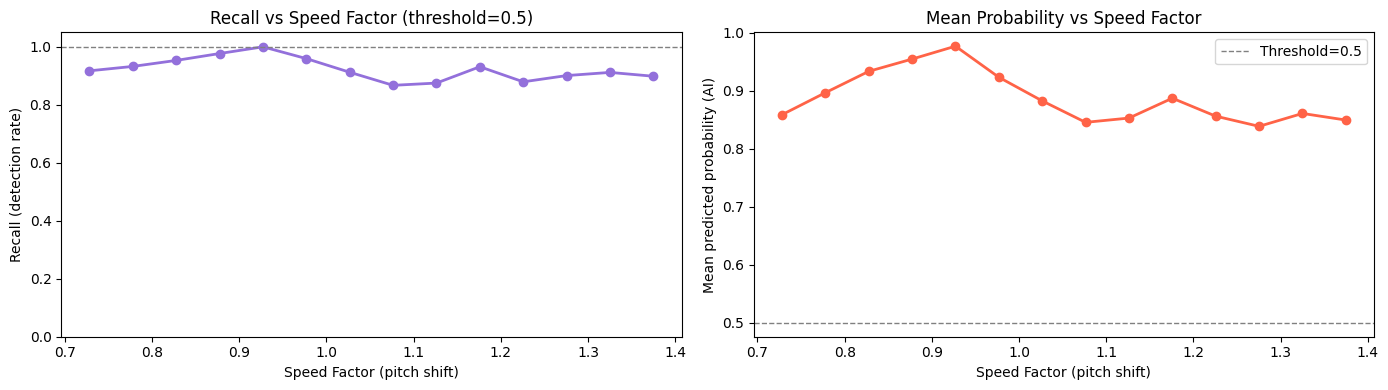

In [30]:
bins = np.linspace(sfs.min(), sfs.max(), 15)
bin_centers, bin_recall, bin_mean_prob = [], [], []

for i in range(len(bins) - 1):
    mask_b = (sfs >= bins[i]) & (sfs < bins[i+1])
    if mask_b.sum() < 5:
        continue
    p_bin = probs[mask_b]
    bin_centers.append((bins[i] + bins[i+1]) / 2)
    bin_recall.append((p_bin >= THRESHOLD).mean())
    bin_mean_prob.append(p_bin.mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(bin_centers, bin_recall, marker='o', color='mediumpurple', lw=2)
ax.axhline(1.0, color='grey', linestyle='--', lw=1)
ax.set_xlabel('Speed Factor (pitch shift)')
ax.set_ylabel('Recall (detection rate)')
ax.set_title(f'Recall vs Speed Factor (threshold={THRESHOLD})')
ax.set_ylim(0, 1.05)

ax = axes[1]
ax.plot(bin_centers, bin_mean_prob, marker='o', color='tomato', lw=2)
ax.axhline(THRESHOLD, color='grey', linestyle='--', lw=1, label=f'Threshold={THRESHOLD}')
ax.set_xlabel('Speed Factor (pitch shift)')
ax.set_ylabel('Mean predicted probability (AI)')
ax.set_title('Mean Probability vs Speed Factor')
ax.legend()

plt.tight_layout()
plt.show()